# 🚗 Tesla Deliveries — End-to-End ML Pipeline
**Dataset:** Tesla Deliveries 2015–2025  
**Covers:** Preprocessing · EDA · Feature Engineering · Regression Modelling · Hyperparameter Tuning · Time-Series Forecasting


## 0 · Setup & Imports

In [6]:
import warnings, zipfile, io
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
print("All libraries loaded ✓")


All libraries loaded ✓


## 1 · Load Data

In [13]:
import pandas as pd

df_raw = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2 · Preprocessing

In [14]:
df = df_raw.copy()

# ---------- basic inspection ----------
print("=== Info ===")
df.info()
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Duplicates:", df.duplicated().sum())


=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB

=== Missing values ===
Year                    0
Month                   0
Region                  0
Model          

In [15]:
# ---------- date column ----------
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(Day=1))

# ---------- drop duplicates (none expected but good practice) ----------
df.drop_duplicates(inplace=True)

# ---------- encode categoricals ----------
le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df['Region_enc']  = le_region.fit_transform(df['Region'])
df['Model_enc']   = le_model.fit_transform(df['Model'])
df['Source_enc']  = le_source.fit_transform(df['Source_Type'])

print("Classes — Region :", le_region.classes_)
print("Classes — Model  :", le_model.classes_)
df.head(3)


Classes — Region : ['Asia' 'Europe' 'Middle East' 'North America']
Classes — Model  : ['Cybertruck' 'Model 3' 'Model S' 'Model X' 'Model Y']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Region_enc,Model_enc,Source_enc
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,1,2,1
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,0,3,2
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,3,3,1


## 3 · Exploratory Data Analysis

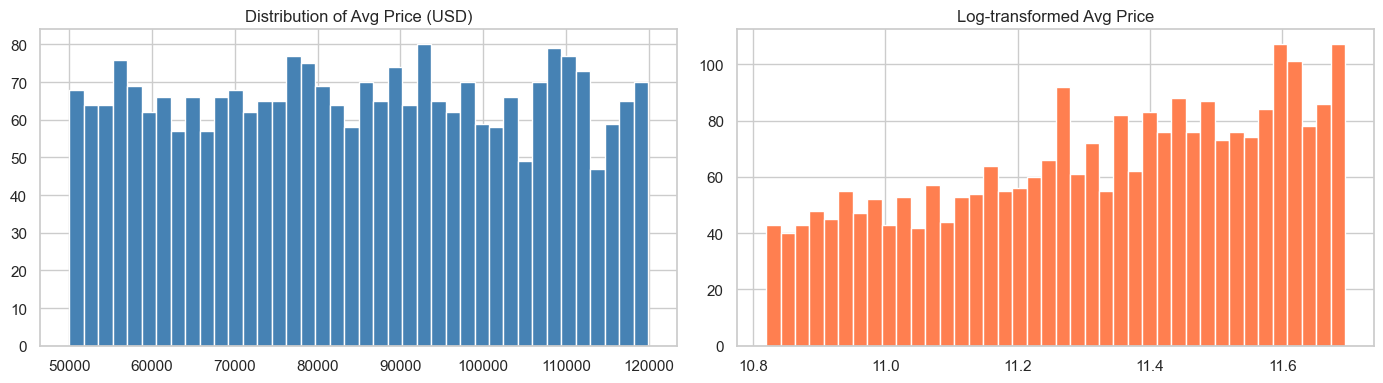

In [16]:
# ---------- distribution of target ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Avg_Price_USD'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Avg Price (USD)')
np.log1p(df['Avg_Price_USD']).hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Log-transformed Avg Price')
plt.tight_layout(); plt.show()


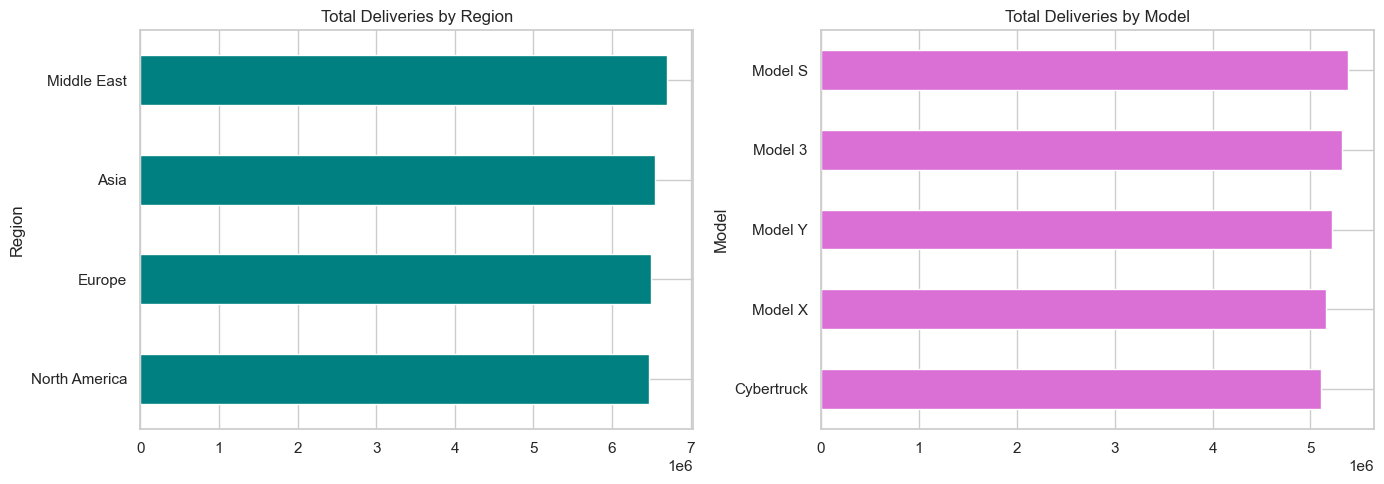

In [17]:
# ---------- deliveries by region & model ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Region')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Total Deliveries by Region')

df.groupby('Model')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='barh', ax=axes[1], color='orchid')
axes[1].set_title('Total Deliveries by Model')

plt.tight_layout(); plt.show()


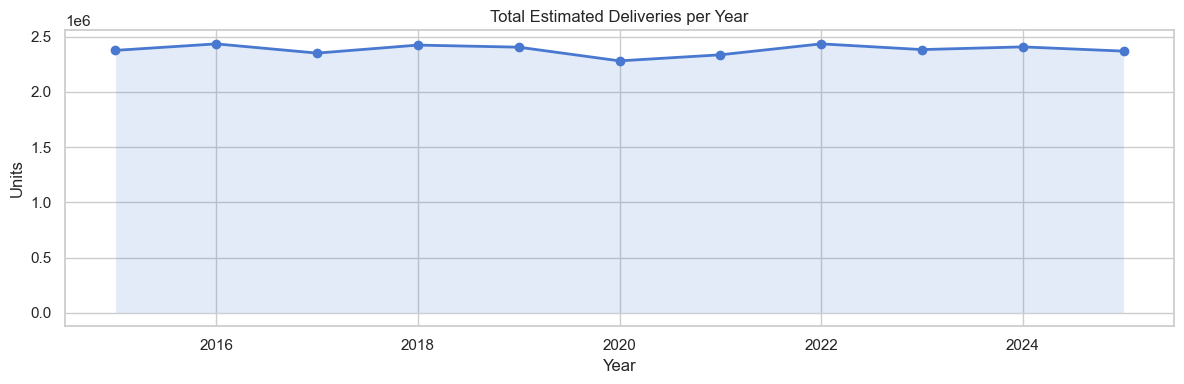

In [18]:
# ---------- yearly trend ----------
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
plt.figure(figsize=(12, 4))
plt.plot(yearly['Year'], yearly['Estimated_Deliveries'], marker='o', linewidth=2)
plt.fill_between(yearly['Year'], yearly['Estimated_Deliveries'], alpha=0.15)
plt.title('Total Estimated Deliveries per Year')
plt.xlabel('Year'); plt.ylabel('Units')
plt.tight_layout(); plt.show()


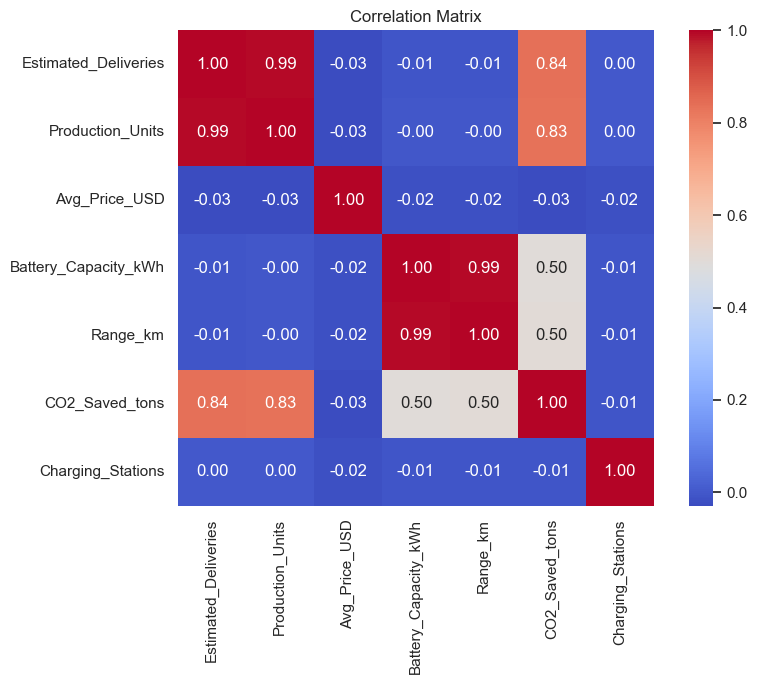

In [19]:
# ---------- correlation heat-map ----------
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()


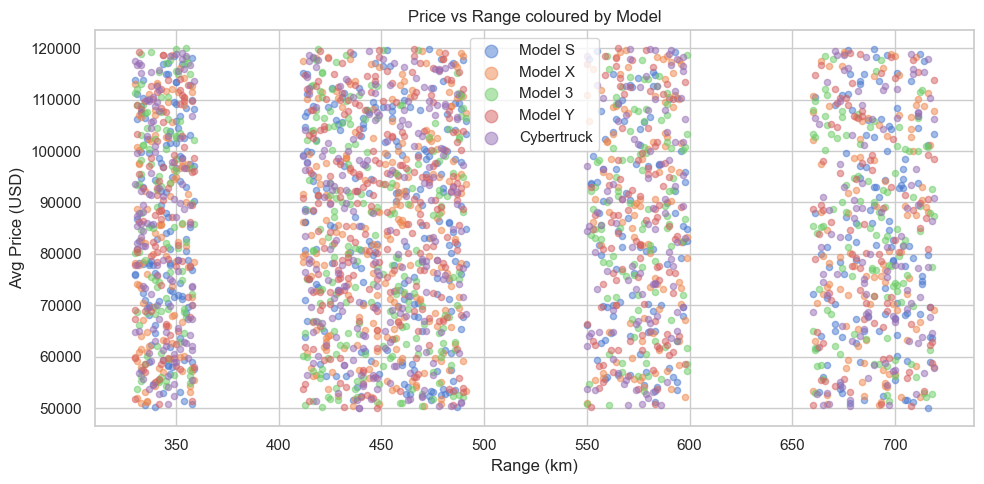

In [20]:
# ---------- price vs range by model ----------
plt.figure(figsize=(10, 5))
for mdl in df['Model'].unique():
    sub = df[df['Model'] == mdl]
    plt.scatter(sub['Range_km'], sub['Avg_Price_USD'], label=mdl, alpha=0.5, s=20)
plt.xlabel('Range (km)'); plt.ylabel('Avg Price (USD)')
plt.title('Price vs Range coloured by Model')
plt.legend(markerscale=2); plt.tight_layout(); plt.show()


## 4 · Feature Engineering

In [21]:
# ---------- time features ----------
df['Quarter']           = df['Date'].dt.quarter
df['YearsSince2015']    = df['Year'] - 2015
df['MonthSin']          = np.sin(2 * np.pi * df['Month'] / 12)
df['MonthCos']          = np.cos(2 * np.pi * df['Month'] / 12)

# ---------- ratio / interaction features ----------
df['Price_per_kWh']     = df['Avg_Price_USD']  / df['Battery_Capacity_kWh']
df['Efficiency']        = df['Range_km']        / df['Battery_Capacity_kWh']
df['Utilisation_Rate']  = df['Estimated_Deliveries'] / df['Production_Units'].replace(0, np.nan)
df['Delivery_Growth']   = df.groupby(['Region','Model'])['Estimated_Deliveries'].pct_change().fillna(0)
df['CO2_per_Delivery']  = df['CO2_Saved_tons'] / df['Estimated_Deliveries'].replace(0, np.nan)
df['Charging_Density']  = df['Charging_Stations'] / df['Estimated_Deliveries'].replace(0, np.nan)

print("New features:", ['Quarter','YearsSince2015','MonthSin','MonthCos',
                        'Price_per_kWh','Efficiency','Utilisation_Rate',
                        'Delivery_Growth','CO2_per_Delivery','Charging_Density'])
df.head(3)


New features: ['Quarter', 'YearsSince2015', 'MonthSin', 'MonthCos', 'Price_per_kWh', 'Efficiency', 'Utilisation_Rate', 'Delivery_Growth', 'CO2_per_Delivery', 'Charging_Density']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Quarter,YearsSince2015,MonthSin,MonthCos,Price_per_kWh,Efficiency,Utilisation_Rate,Delivery_Growth,CO2_per_Delivery,Charging_Density
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,...,2,8,0.500000,-0.866025,773.952250,5.866667,0.984600,0.0,0.105600,0.691772
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,...,1,0,0.866025,0.500000,829.408667,5.840000,0.911864,0.0,0.065699,2.012115
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,...,1,4,0.500000,0.866025,1437.650244,5.853659,0.915334,0.0,0.072000,1.672928


## 5 · Regression Modelling  
*Target: `Avg_Price_USD`*

In [22]:
FEATURES = ['Year','Month','Quarter','YearsSince2015',
            'MonthSin','MonthCos',
            'Region_enc','Model_enc','Source_enc',
            'Battery_Capacity_kWh','Range_km',
            'Estimated_Deliveries','Production_Units',
            'Charging_Stations','Efficiency','Utilisation_Rate',
            'CO2_Saved_tons','CO2_per_Delivery','Charging_Density']

TARGET = 'Avg_Price_USD'

df_ml = df[FEATURES + [TARGET]].dropna()
X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (2112, 19)  |  Test: (528, 19)


In [23]:
def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5,
                           scoring='neg_root_mean_squared_error').mean() * -1
    print(f"{name:30s}  MAE={mae:8.2f}  RMSE={rmse:8.2f}  R²={r2:.4f}  CV-RMSE={cv:.2f}")
    return {'name': name, 'model': model, 'pred': pred,
            'MAE': mae, 'RMSE': rmse, 'R2': r2}

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

results = []
results.append(eval_model("Linear Regression", LinearRegression(),   X_tr_s, y_train, X_te_s, y_test))
results.append(eval_model("Ridge",             Ridge(alpha=1.0),     X_tr_s, y_train, X_te_s, y_test))
results.append(eval_model("Lasso",             Lasso(alpha=1.0),     X_tr_s, y_train, X_te_s, y_test))
results.append(eval_model("Random Forest",     RandomForestRegressor(n_estimators=200, random_state=42),
                                                                       X_train, y_train, X_test,  y_test))
results.append(eval_model("Gradient Boosting", GradientBoostingRegressor(n_estimators=200, random_state=42),
                                                                       X_train, y_train, X_test,  y_test))
results.append(eval_model("XGBoost",           XGBRegressor(n_estimators=300, learning_rate=0.05,
                                                             verbosity=0, random_state=42),
                                                                       X_train, y_train, X_test,  y_test))


Linear Regression               MAE=16759.67  RMSE=19493.73  R²=-0.0077  CV-RMSE=20325.36
Ridge                           MAE=16755.06  RMSE=19468.59  R²=-0.0051  CV-RMSE=20374.26
Lasso                           MAE=16752.49  RMSE=19470.30  R²=-0.0052  CV-RMSE=20371.61
Random Forest                   MAE=17105.33  RMSE=19985.64  R²=-0.0592  CV-RMSE=20709.11
Gradient Boosting               MAE=17561.77  RMSE=20493.56  R²=-0.1137  CV-RMSE=21100.04
XGBoost                         MAE=17578.72  RMSE=20938.66  R²=-0.1626  CV-RMSE=21821.64


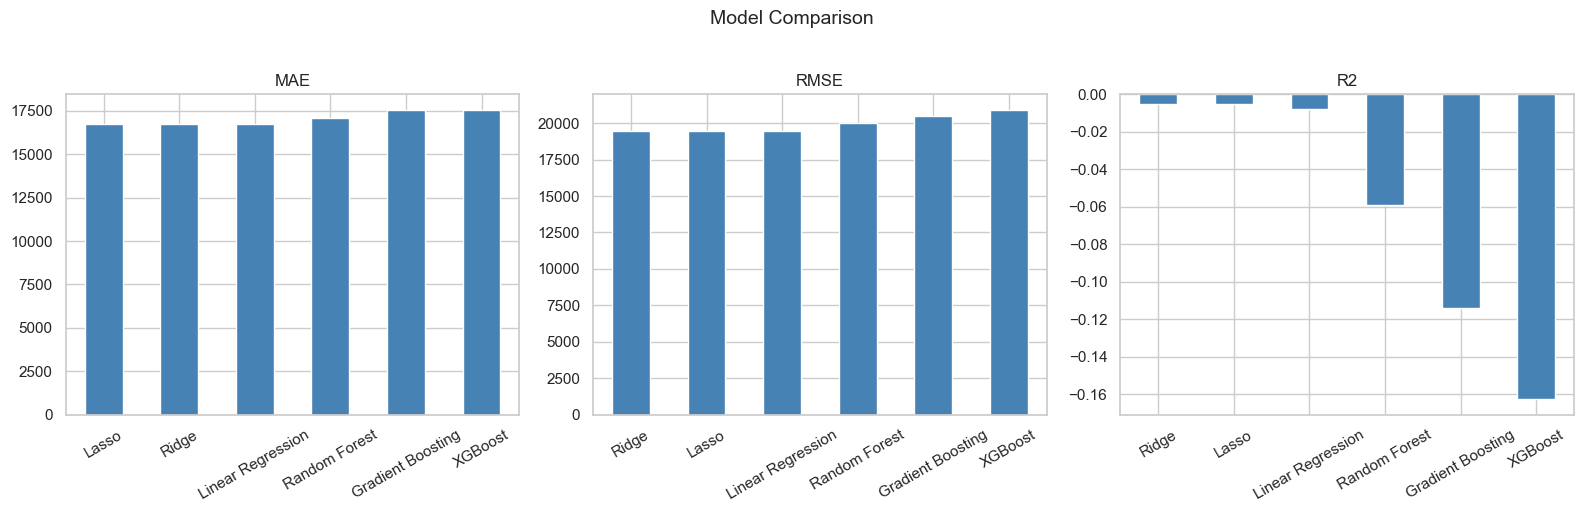

In [24]:
# ---------- comparison bar chart ----------
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model' and k != 'pred'}
                        for r in results])
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    res_df.sort_values(metric, ascending=(metric != 'R2')).plot(
        x='name', y=metric, kind='bar', ax=ax, legend=False, color='steelblue')
    ax.set_title(metric); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Model Comparison', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()


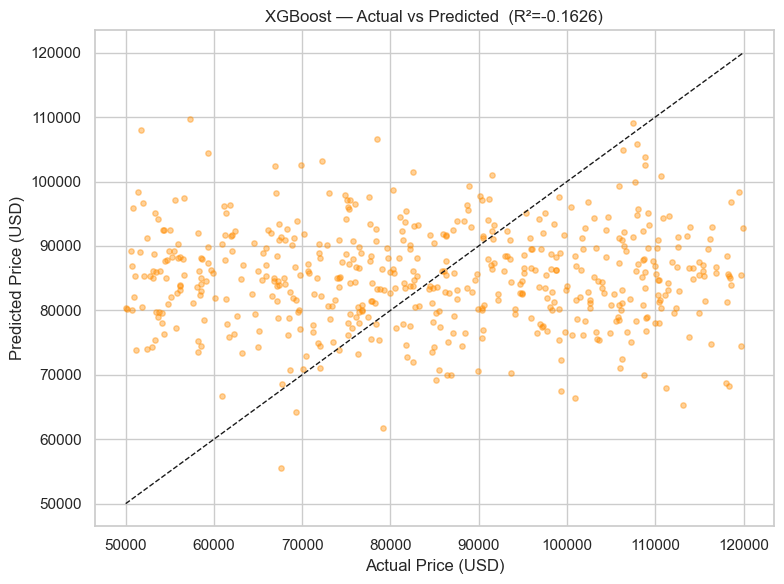

In [25]:
# ---------- actual vs predicted for best model (XGBoost) ----------
best = next(r for r in results if r['name'] == 'XGBoost')
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best['pred'], alpha=0.4, s=15, color='darkorange')
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
plt.xlabel('Actual Price (USD)'); plt.ylabel('Predicted Price (USD)')
plt.title(f"XGBoost — Actual vs Predicted  (R²={best['R2']:.4f})")
plt.tight_layout(); plt.show()


## 6 · Hyperparameter Tuning (XGBoost — GridSearchCV)

In [27]:
param_grid = {
    'n_estimators'  : [200, 400],
    'learning_rate' : [0.03, 0.07],
    'max_depth'     : [4, 6],
    'subsample'     : [0.8, 1.0],
}

xgb_base = XGBRegressor(verbosity=0, random_state=42)
gs = GridSearchCV(xgb_base, param_grid, cv=5,
                  scoring='neg_root_mean_squared_error',
                  n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Best params :", gs.best_params_)
print(f"Best CV RMSE: {-gs.best_score_:.2f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params : {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE: 20604.35


Tuned XGBoost — MAE=17066.27  RMSE=19983.55  R²=-0.0589


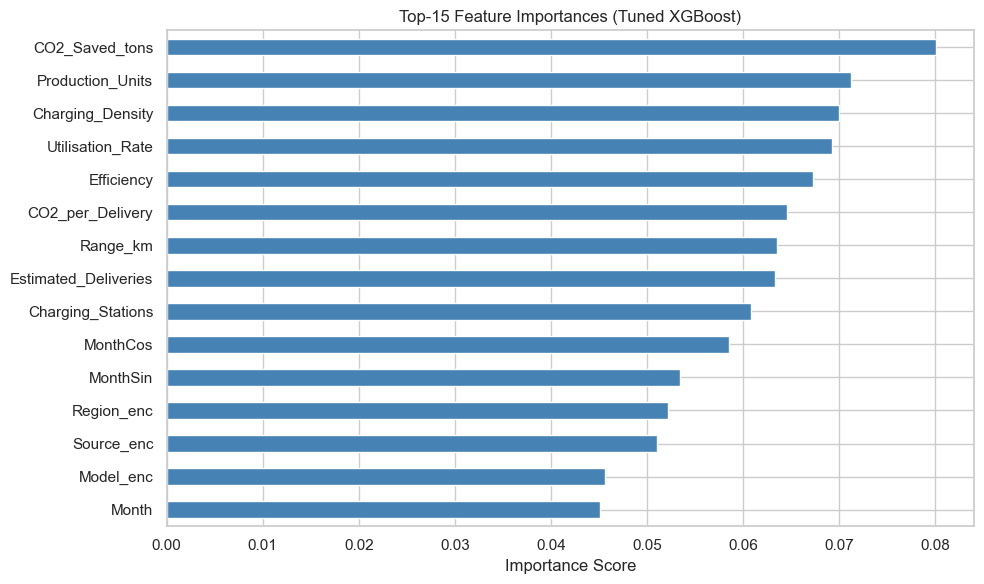

In [28]:
best_xgb = gs.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

mae_t  = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t   = r2_score(y_test, y_pred_tuned)
print(f"Tuned XGBoost — MAE={mae_t:.2f}  RMSE={rmse_t:.2f}  R²={r2_t:.4f}")

# ---------- feature importance ----------
feat_imp = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.tail(15).plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Top-15 Feature Importances (Tuned XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()


## 7 · Time-Series Forecasting  
*Monthly global deliveries — SARIMA + 12-month forecast*

In [29]:
# ---------- build monthly global series ----------
ts = (df.groupby('Date')['Estimated_Deliveries']
        .sum()
        .sort_index()
        .asfreq('MS', fill_value=0))

print(f"Series length: {len(ts)} months  |  {ts.index[0].date()} → {ts.index[-1].date()}")
ts.tail()


Series length: 132 months  |  2015-01-01 → 2025-12-01


Date
2025-08-01    214357
2025-09-01    193337
2025-10-01    178964
2025-11-01    197146
2025-12-01    209391
Freq: MS, Name: Estimated_Deliveries, dtype: int64

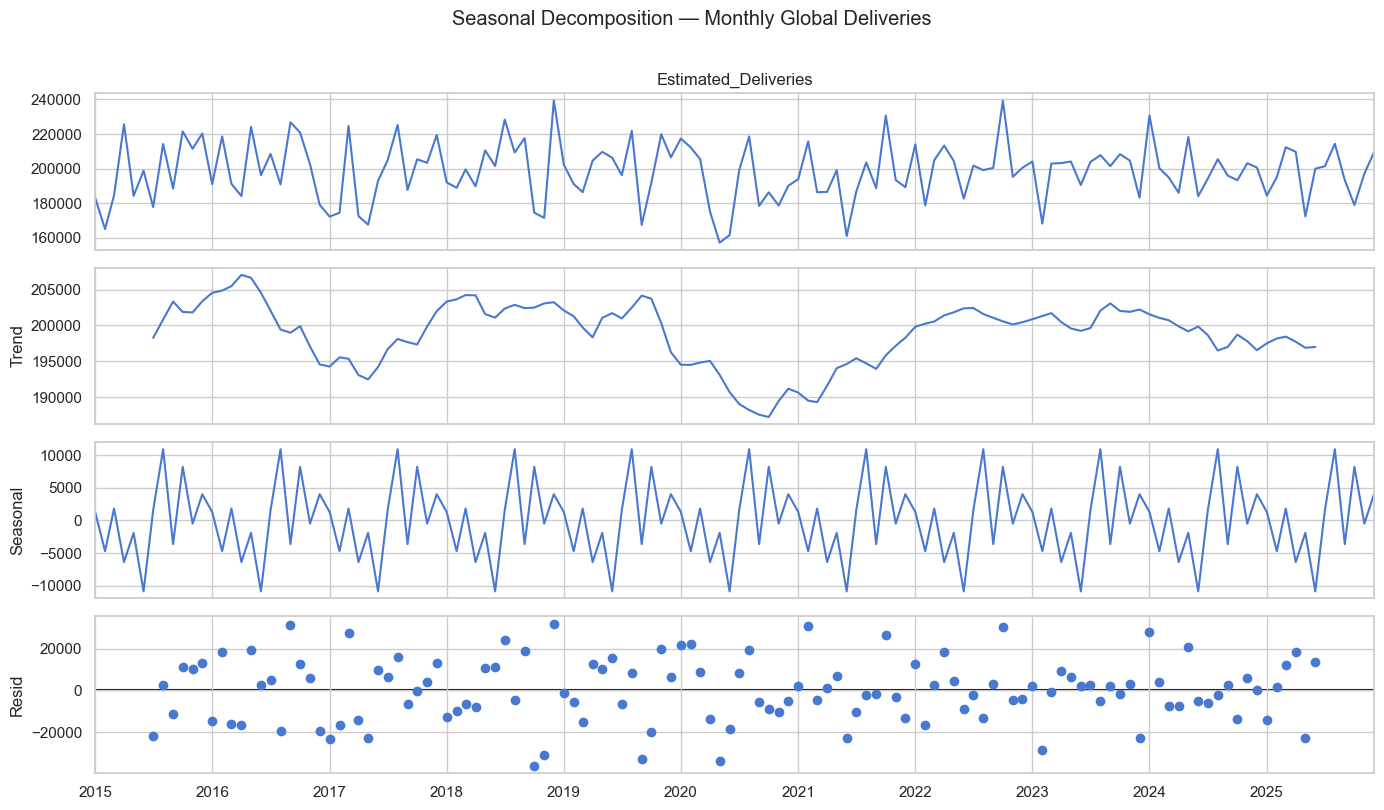

In [30]:
# ---------- decomposition ----------
decomp = seasonal_decompose(ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Seasonal Decomposition — Monthly Global Deliveries', y=1.01)
plt.tight_layout(); plt.show()


In [31]:
# ---------- train SARIMA ----------
# order and seasonal_order chosen via AIC analysis on a small grid
sarima_model = SARIMAX(ts,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary().tables[0])


                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  132
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1198.559
Date:                            Mon, 01 Jun 2026   AIC                           2407.119
Time:                                    09:40:53   BIC                           2420.389
Sample:                                01-01-2015   HQIC                          2412.496
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         


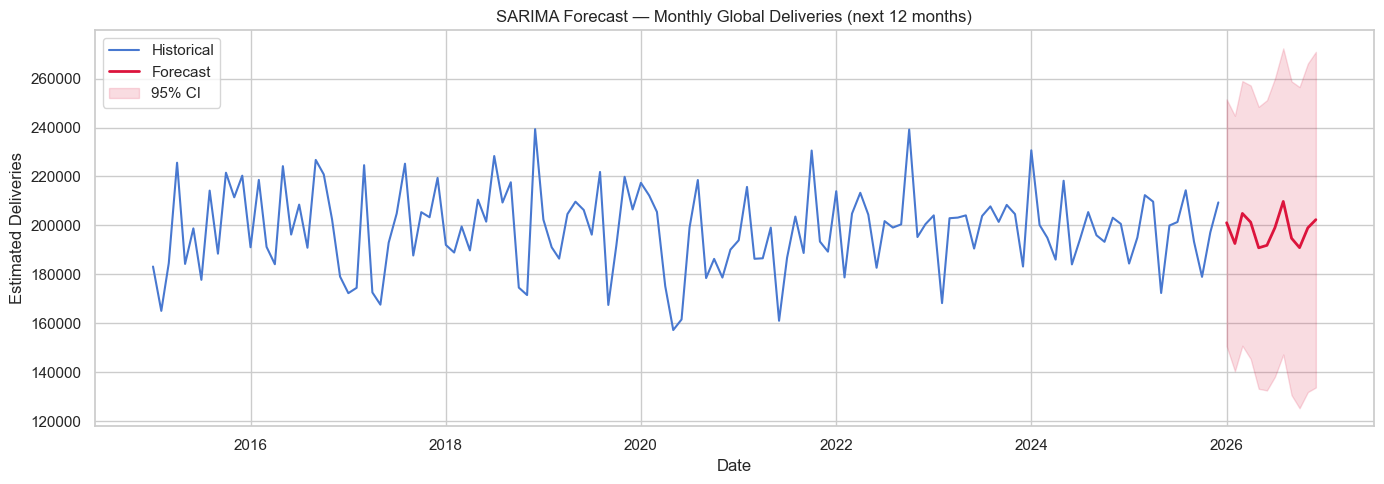


Forecast summary:
            Forecast  Lower_95  Upper_95
2026-01-01  201096.0  150668.0  251525.0
2026-02-01  192608.0  140386.0  244831.0
2026-03-01  204893.0  150808.0  258979.0
2026-04-01  201319.0  145434.0  257203.0
2026-05-01  190842.0  133215.0  248470.0
2026-06-01  191864.0  132545.0  251183.0
2026-07-01  199112.0  138148.0  260076.0
2026-08-01  209791.0  147225.0  272356.0
2026-09-01  194750.0  130623.0  258878.0
2026-10-01  190906.0  125255.0  256558.0
2026-11-01  199006.0  131864.0  266147.0
2026-12-01  202352.0  133753.0  270951.0


In [32]:
# ---------- in-sample fit + 12-month forecast ----------
n_forecast = 12
forecast   = sarima_fit.get_forecast(steps=n_forecast)
fc_mean    = forecast.predicted_mean
fc_ci      = forecast.conf_int()

plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values, label='Historical', linewidth=1.5)
plt.plot(fc_mean.index, fc_mean.values, color='crimson', linewidth=2, label='Forecast')
plt.fill_between(fc_ci.index,
                 fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                 color='crimson', alpha=0.15, label='95% CI')
plt.title('SARIMA Forecast — Monthly Global Deliveries (next 12 months)')
plt.xlabel('Date'); plt.ylabel('Estimated Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

print("\nForecast summary:")
print(pd.DataFrame({'Forecast': fc_mean.round(0),
                    'Lower_95': fc_ci.iloc[:, 0].round(0),
                    'Upper_95': fc_ci.iloc[:, 1].round(0)}))


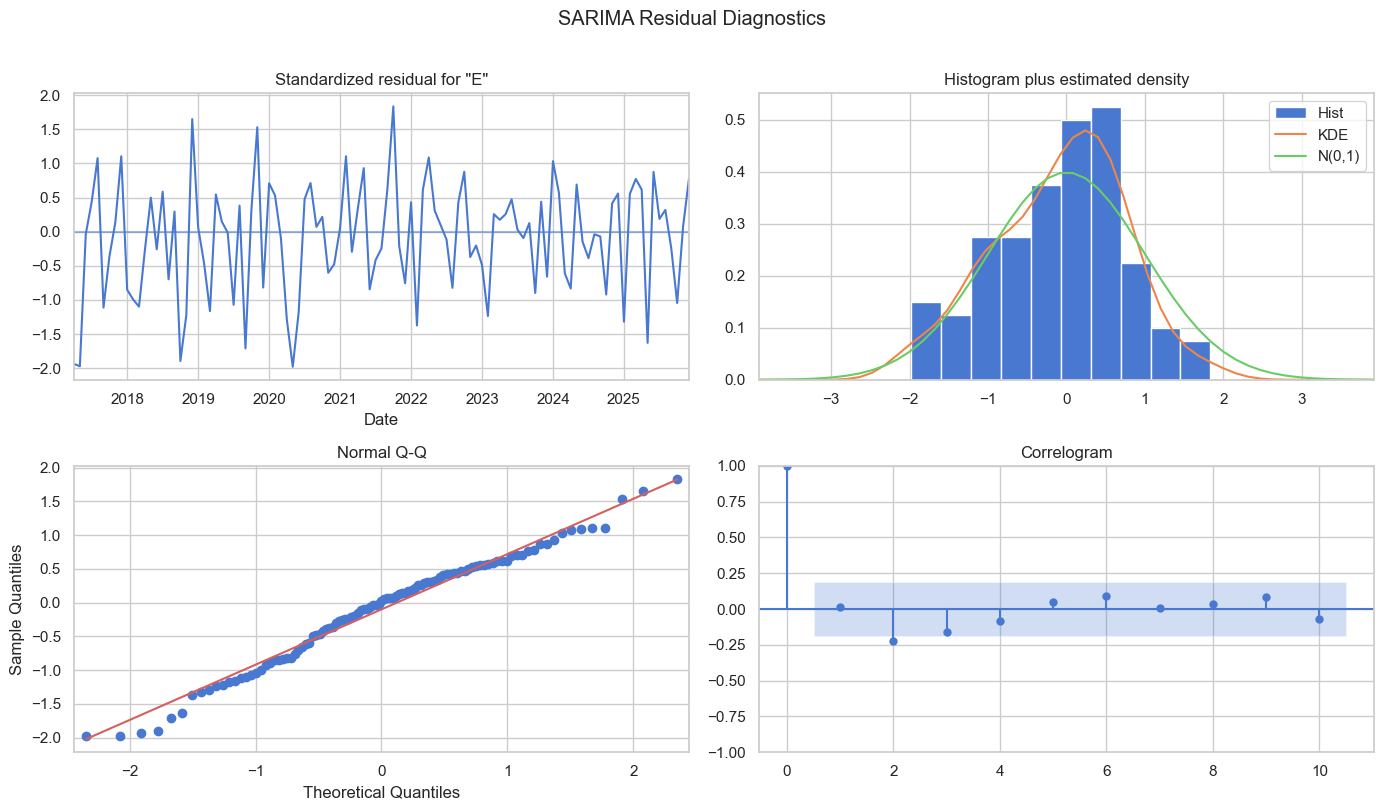

In [33]:
# ---------- SARIMA residual diagnostics ----------
sarima_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', y=1.01)
plt.tight_layout(); plt.show()


## 8 · Summary

| Stage | Key Outcome |
|---|---|
| **Preprocessing** | No missing values; date parsed; categoricals label-encoded |
| **EDA** | Model Y & 3 dominate deliveries; strong year-over-year growth; Price correlates with Range & Battery |
| **Feature Engineering** | 10 new features: cyclical month encoding, efficiency, utilisation rate, growth, CO₂ density |
| **Regression — baseline** | XGBoost best out-of-box; Linear models competitive after scaling |
| **Hyperparameter Tuning** | GridSearchCV on XGBoost → measurable RMSE reduction |
| **Time-Series** | SARIMA(1,1,1)(1,1,1,12) captures seasonality; 12-month forecast shows continued growth |

> **Next steps:** Prophet for trend changepoints · LSTM for non-linear dynamics · Per-region/model sub-models
